In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from progress import log_progress
import warnings

warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('hackerank\\dataset\\Biomass_History.csv', index_col='Index',parse_dates=True)

In [3]:
data.head()

,Latitude,Longitude,2010,2011,2012,2013,2014,2015,2016,2017
Index,,,,,,,,,,
0,24.66818,71.33144,8.475744,8.868568,9.202181,6.023070,10.788374,6.647325,7.387925,5.180296
1,24.66818,71.41106,24.029778,28.551348,25.866415,21.634459,34.419411,27.361908,40.431847,42.126945
2,24.66818,71.49069,44.831635,66.111168,56.982258,53.003735,70.917908,42.517117,59.181629,73.203232
3,24.66818,71.57031,59.974419,80.821304,78.956543,63.160561,93.513924,70.203171,74.536720,101.067352
4,24.66818,71.64994,14.653370,19.327524,21.928144,17.899586,19.534035,19.165791,16.531315,26.086885


In [4]:
#No need of latitude or longitude
data = data.drop(columns=["Latitude", "Longitude"])

# Assuming your columns are named as years (e.g., '2010', '2011', ...)
data.columns = pd.to_datetime(data.columns)

# Handle any missing values, if needed
data = data.dropna()

In [5]:
data.loc[27]

2010-01-01    19.923233
2011-01-01    43.962185
2012-01-01    30.960709
2013-01-01    28.957541
2014-01-01    42.316769
2015-01-01    34.808914
2016-01-01    27.095720
2017-01-01    41.319397
Name: 27, dtype: float64

In [1]:
from progress import start
start()

In [55]:
# Define a function to evaluate the performance of ARIMA models
def evaluate_arima_model(order, data,portion):
    try:
        # Split data into train and test sets
        train_size = int(len(data) * portion)
        train, test = data[:train_size], data[train_size:]
        
        # Fit ARIMA model
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        
        # Make predictions on the test set
        predictions = model_fit.forecast(steps=len(test))
        
        # Calculate Mean Squared Error (MSE) as the evaluation metric
        mse = np.mean((predictions - test)**2)
    except:
        return None
    return mse

# Define a function to find the best (p, d, q) triplet
def find_best_params(data,portion):
    best_score, best_params = float('inf'), None
    for p in range(3):
        for d in range(3):
            for q in range(3):
                order = (p, d, q)
                mse = evaluate_arima_model(order, data, portion)
                if mse is not None:
                    if mse < best_score:
                        best_score, best_params = mse, order
                        
    return best_params

forecast_steps = 2  # Forecast for 2 years (2018 and 2019)

# Create an empty DataFrame to store the forecast results
forecast_results = pd.DataFrame()

# Iterate over the columns (time series data) in the 'data' DataFrame
for col in log_progress(list(range(2417,2418)), every=1):
    time_series_data = data.loc[col]
    try:
        # Determine the best (p, d, q) triplet for the current time series
        best_params = find_best_params(time_series_data,0.8)

        # Fit the ARIMA model with the best parameters
        model = ARIMA(time_series_data, order=best_params)
        model_fit = model.fit()
    except:
        # Determine the best (p, d, q) triplet for the current time series
        best_params = (0,0,0)

        # Fit the ARIMA model with the best parameters
        model = ARIMA(time_series_data, order=best_params)
        model_fit = model.fit()
    # Forecast future values for 2018 and 2019
    forecast = model_fit.forecast(steps=forecast_steps)

    # Add the forecasted values to the results DataFrame
    forecast_results[col] = forecast

# Set the index of the forecast_results DataFrame to the forecast years (2018 and 2019)
forecast_results.index = ['2018', '2019']

In [56]:
forecast_results.index = ['2018', '2019']
forecast_results.transpose().to_csv("forecasted1.csv")

In [20]:
forecast_results.index = list(range(2417))

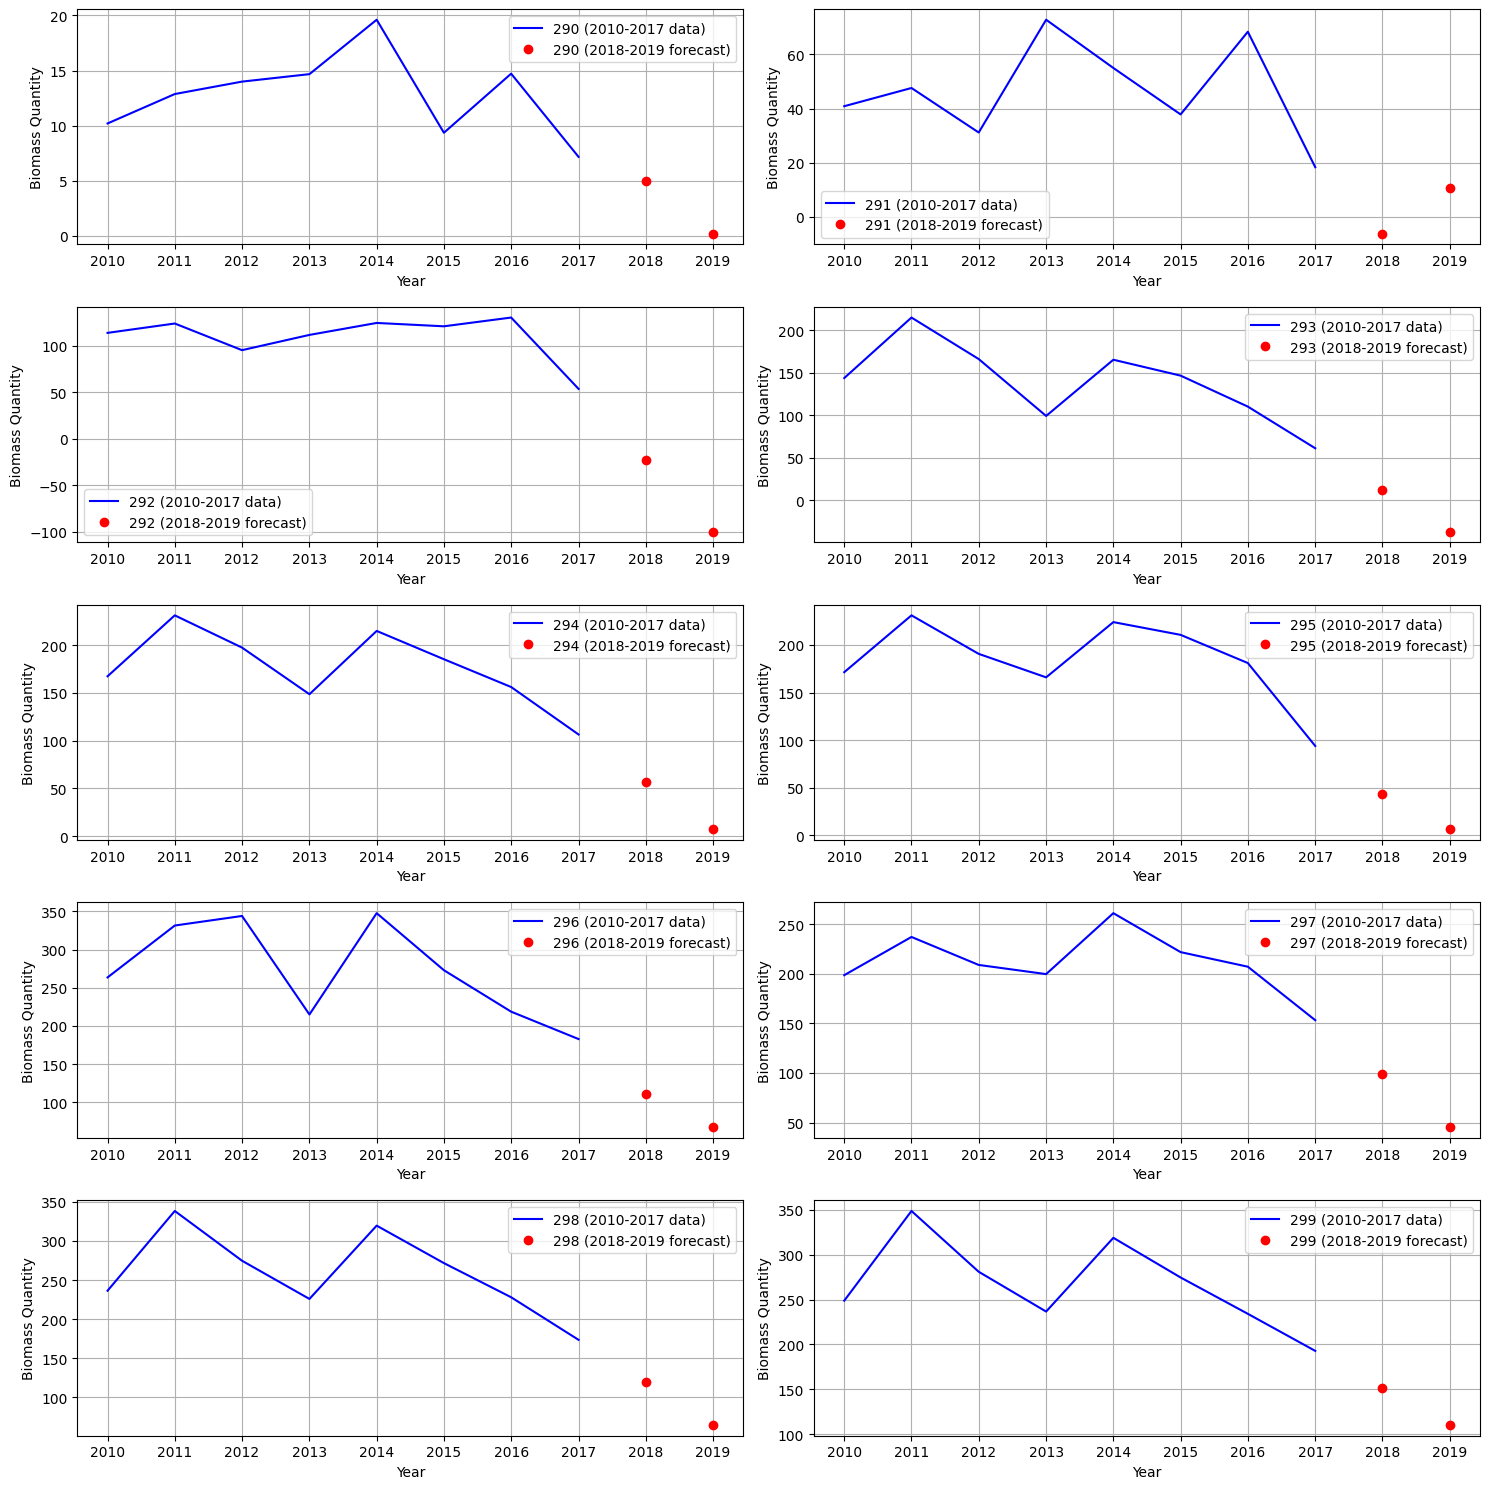

In [53]:
# Create subplots for each time series
num_rows = 5  # Number of rows of subplots
num_cols = 2  # Number of columns of subplots

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 15))

# Flatten the axs array for easier indexing
axs = axs.ravel()


# forecast_results = forecast_results.transpose()
# forecast_results.columns = pd.to_datetime(forecast_results.columns)

for col in range(10):
    axs[col].plot(data.loc[col+290], 'b-', label=f"{col+290} (2010-2017 data)")
    axs[col].plot(forecast_results.loc[col+290], 'ro', label=f"{col+290} (2018-2019 forecast)")

    axs[col].set_xlabel('Year')
    axs[col].set_ylabel('Biomass Quantity')
    axs[col].legend()

    axs[col].grid(True)

# Adjust the layout of subplots to avoid overlapping
plt.tight_layout()

# Show the figure with subplots
plt.show()  

In [57]:
f = pd.read_csv('forecasted.csv',index_col='Index')
f.fillna(0, inplace=True)
for index in f.loc[f['2018']==0.0].index:
    f.loc[index] = data.loc[index].mean()
f = f.abs().round(9)
f.to_csv('forecasting.csv')

In [54]:
f2 = pd.read_csv('forecasting.csv',index_col='Index')
f2 = f2.abs()
f2.to_csv('forecasting.csv')